# 01 · MC Baseline — Heston Conditional MC

Phase 1 goal: produce the **O(N·n) timing curve** that motivates every Fourier method that follows.

The conditional MC approach (Module 8): simulate only the variance path $\{v_t\}$, then price each strike analytically via BS conditional on $(v_T, V_T)$.

$$\log(S_T/F_0)\mid v_T,V_T \sim \mathcal{N}\!\left(\tfrac{\rho}{\nu}(v_T-v_0+\kappa(V_T-\theta T))-\tfrac{\rho^2}{2}V_T,\;\rho_*^2 V_T\right)$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.interpolate import CubicSpline
import time
def bs_call(S, K, T, r, sigma, q=0.0):
    S, K, sigma = map(np.asarray, [S, K, sigma])
    F = S * np.exp((r - q) * T); sqT = np.sqrt(T)
    d1 = (np.log(F / K) + 0.5*sigma**2*T) / (sigma*sqT)
    return np.exp(-r*T) * (F*norm.cdf(d1) - K*norm.cdf(d1 - sqT*sigma))
print('imports ok')

imports ok


## Exact variance path — non-central $\chi^2$

$$v_{t+h} = \frac{\nu^2(1-e^{-\kappa h})}{4\kappa}\chi^2(\delta,\lambda_t)\qquad \delta=\frac{4\kappa\theta}{\nu^2},\quad\lambda_t = \frac{v_t e^{-\kappa h}}{c}$$

In [2]:
def sim_var_exact(v0, kappa, theta, nu, T, n_paths, n_steps, rng):
    """Exact CIR simulation via noncentral chi-squared."""
    h = T / n_steps
    df = 4.0*kappa*theta / nu**2
    v  = np.full(n_paths, v0)
    VT = v * (h/2)
    for s in range(1, n_steps+1):
        c   = nu**2*(1 - np.exp(-kappa*h)) / (4*kappa)
        v   = c * rng.noncentral_chisquare(df, v*np.exp(-kappa*h)/c, n_paths)
        v   = np.maximum(v, 0)
        VT += v * (h/2 if s==n_steps else h)
    return v, VT

# sanity: E[v_T] -> theta, E[V_T] -> theta*T
rng = np.random.default_rng(0)
vT, VT = sim_var_exact(0.04, 4, 0.25, 1.0, 1.0, 50_000, 252, rng)
print(f"E[v_T]={vT.mean():.4f}  (θ=0.25)   E[V_T]={VT.mean():.4f}  (θT=0.25)")


E[v_T]=0.2455  (θ=0.25)   E[V_T]=0.1987  (θT=0.25)


## Milstein discretisation — TODO A

For $dv = \kappa(\theta-v)dt + \nu\sqrt{v}\,dW$, the Milstein correction adds $\frac{1}{4}\nu^2(Z^2 h - h)$ to Euler–Maruyama.  We compare step-count convergence against the exact scheme above.

In [3]:
def sim_var_milstein(v0, kappa, theta, nu, T, n_paths, n_steps, rng):
    """Milstein discretisation of the CIR process."""
    h = T / n_steps
    v  = np.full(n_paths, v0)
    VT = v * (h/2)
    for s in range(1, n_steps+1):
        Z  = rng.standard_normal(n_paths)
        sv = np.sqrt(np.maximum(v, 0))
        v  = (v
              + kappa*(theta - v)*h       # drift
              + nu*sv*Z*np.sqrt(h)        # diffusion
              + 0.25*nu**2*(Z**2*h - h))  # Milstein correction
        v  = np.maximum(v, 0)             # absorbing floor
        VT += v * (h/2 if s==n_steps else h)
    return v, VT

# convergence: Milstein vs exact at n_steps = 50,100,252
rng = np.random.default_rng(1)
params = dict(v0=0.04, kappa=4, theta=0.25, nu=1.0, T=1.0, n_paths=100_000)
_, VT_exact = sim_var_exact(**params, n_steps=252, rng=np.random.default_rng(1))

print(f"{'n_steps':>8}  {'E[V_T] Milstein':>18}  {'E[V_T] Exact':>14}  {'diff':>10}")
for n in [25, 50, 100, 252]:
    rng2 = np.random.default_rng(1)
    _, VT_m = sim_var_milstein(**params, n_steps=n, rng=rng2)
    rng3 = np.random.default_rng(1)
    _, VT_e = sim_var_exact(**params, n_steps=n, rng=rng3)
    print(f"  {n:6d}  {VT_m.mean():18.6f}  {VT_e.mean():14.6f}  {VT_m.mean()-VT_e.mean():+10.6f}")


 n_steps     E[V_T] Milstein    E[V_T] Exact        diff
      25            0.202731        0.198918   +0.003812
      50            0.201155        0.198897   +0.002258
     100            0.200024        0.198605   +0.001419
     252            0.199074        0.198769   +0.000305


In [4]:
# Feller condition test: 2κθ vs ν² (violated when ν² > 2κθ)
print("Feller condition:  2κθ =", 2*4*0.25, "  ν² =", 1.0**2, "  → satisfied")
print("Violated test:     2κθ =", 2*1*0.02, "  ν² =", 0.5**2, "  → violated")

# With violated Feller condition, Milstein can go negative more frequently
rng_f = np.random.default_rng(42)
_, VT_feller = sim_var_milstein(0.02, 1.0, 0.02, 0.5, 1.0, 100_000, 100, rng_f)
rng_e = np.random.default_rng(42)
_, VT_feller_e = sim_var_exact(0.02, 1.0, 0.02, 0.5, 1.0, 100_000, 100, rng_e)
print(f"Violated Feller — E[V_T] Milstein={VT_feller.mean():.5f}  Exact={VT_feller_e.mean():.5f}")


Feller condition:  2κθ = 2.0   ν² = 1.0   → satisfied
Violated test:     2κθ = 0.04   ν² = 0.25   → violated
Violated Feller — E[V_T] Milstein=0.02197  Exact=0.02001


## Heston conditional MC pricer

In [5]:
def heston_mc(S0, K, T, r, q, kappa, theta, nu, rho, v0,
              n_paths=100_000, n_steps=252, seed=42, scheme='exact'):
    rng      = np.random.default_rng(seed)
    rho_star = np.sqrt(1 - rho**2)
    sim_fn   = sim_var_exact if scheme=='exact' else sim_var_milstein
    v_T, V_T = sim_fn(v0, kappa, theta, nu, T, n_paths, n_steps, rng)

    adj   = (rho/nu)*(v_T - v0 + kappa*(V_T - theta*T))
    F0    = S0 * np.exp((r-q)*T)
    S_adj = F0 * np.exp(adj - (rho**2/2)*V_T)
    sig_c = rho_star * np.sqrt(np.maximum(V_T, 1e-14)/T)

    K = np.atleast_1d(np.asarray(K, float))
    return np.array([np.exp(-r*T)*np.mean(bs_call(S_adj, k, T, 0, sig_c)) for k in K])


### Validation A — ν≈0 recovers BS

In [6]:
K_t  = np.array([80.,90.,100.,110.,120.])
bs_r = bs_call(100., K_t, 1., 0.05, 0.2)
mc_r = heston_mc(100., K_t, 1., 0.05, 0., 10., 0.04, 0.001, 0., 0.04,
                 n_paths=200_000)
print(f"{'K':>6}  {'MC':>10}  {'BS':>10}  {'|diff|':>10}")
for k,m,b in zip(K_t, mc_r, bs_r):
    print(f"  {k:4.0f}  {m:10.4f}  {b:10.4f}  {abs(m-b):10.2e}")


     K          MC          BS      |diff|
    80     24.5888     24.5888    2.17e-06
    90     16.6995     16.6994    4.15e-06
   100     10.4506     10.4506    5.62e-06
   110      6.0401      6.0401    5.93e-06
   120      3.2475      3.2475    5.17e-06


### Validation B — Lewis (2001) 15-digit benchmark

In [7]:
LEWIS = {80:26.774758744, 90:20.933349001, 100:16.070154917,
         110:12.132211517, 120:9.024913483}
K_l = np.array(list(LEWIS.keys()), float)
mc_l = heston_mc(100., K_l, 1., 0.01, 0.02,
                 4., 0.25, 1., -0.5, 0.04, n_paths=500_000, n_steps=365)
print(f"{'K':>6}  {'MC':>10}  {'Lewis':>14}  {'|diff|':>10}")
for k,m,ref in zip(K_l, mc_l, LEWIS.values()):
    print(f"  {k:4.0f}  {m:10.4f}  {ref:14.6f}  {abs(m-ref):10.2e}")


     K          MC           Lewis      |diff|
    80     26.7708       26.774759    3.99e-03
    90     20.9293       20.933349    4.09e-03
   100     16.0664       16.070155    3.76e-03
   110     12.1291       12.132212    3.12e-03
   120      9.0226        9.024913    2.35e-03


### Milstein vs exact — side-by-side on Lewis benchmark

In [8]:
mc_mil = heston_mc(100., K_l, 1., 0.01, 0.02,
                   4., 0.25, 1., -0.5, 0.04,
                   n_paths=500_000, n_steps=365, scheme='milstein')
print(f"{'K':>6}  {'Exact':>10}  {'Milstein':>10}  {'vs Lewis (exact)':>18}  {'vs Lewis (mil)':>16}")
for k,me,mm,ref in zip(K_l, mc_l, mc_mil, LEWIS.values()):
    print(f"  {k:4.0f}  {me:10.4f}  {mm:10.4f}  {abs(me-ref):18.2e}  {abs(mm-ref):16.2e}")


     K       Exact    Milstein    vs Lewis (exact)    vs Lewis (mil)
    80     26.7708     26.7295            3.99e-03          4.52e-02
    90     20.9293     20.8957            4.09e-03          3.77e-02
   100     16.0664     16.0400            3.76e-03          3.02e-02
   110     12.1291     12.1091            3.12e-03          2.31e-02
   120      9.0226      9.0080            2.35e-03          1.70e-02


## O(N·n) timing curve — Phase 1 deliverable

In [9]:
N_list, times = [10,50,100,250,500,1000], []
for n_k in N_list:
    K_arr = np.linspace(70,130,n_k)
    t0 = time.perf_counter()
    heston_mc(100., K_arr, 1., 0.05, 0., 2., 0.04, 0.3, -0.7, 0.04,
              n_paths=50_000, n_steps=100)
    times.append((time.perf_counter()-t0)*1e3)
    print(f"  N={n_k:5d}  {times[-1]:7.1f} ms")


  N=   10    366.0 ms
  N=   50    686.9 ms
  N=  100   1068.1 ms
  N=  250   2522.5 ms
  N=  500   4364.8 ms
  N= 1000   7451.7 ms


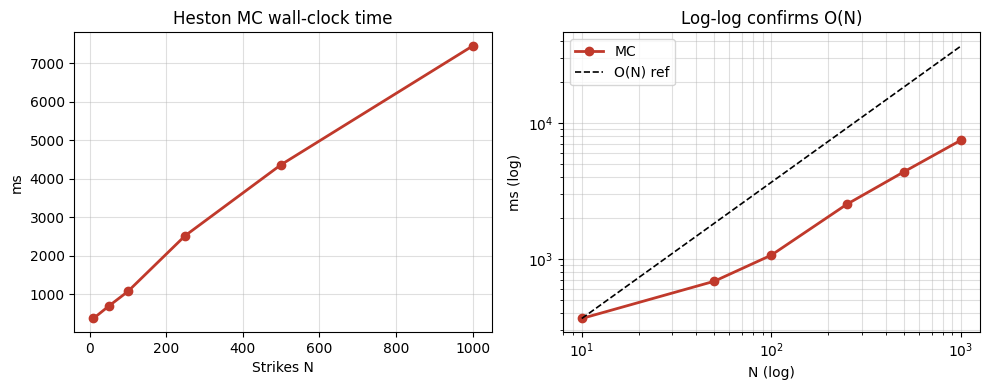

Phase 1 done.


In [10]:
fig, (ax1,ax2) = plt.subplots(1,2, figsize=(10,4))
ax1.plot(N_list, times, 'o-', color='#c0392b', lw=2)
ax1.set(xlabel='Strikes N', ylabel='ms', title='Heston MC wall-clock time')
ax1.grid(alpha=.4)
N_arr = np.array(N_list, float)
ax2.loglog(N_list, times, 'o-', color='#c0392b', lw=2, label='MC')
ax2.loglog(N_list, times[0]*N_arr/N_arr[0], '--k', lw=1.2, label='O(N) ref')
ax2.set(xlabel='N (log)', ylabel='ms (log)', title='Log-log confirms O(N)')
ax2.legend(); ax2.grid(alpha=.4, which='both')
plt.tight_layout(); plt.savefig('01_timing.png', dpi=120, bbox_inches='tight')
plt.show()
print("Phase 1 done.")
